# Task 1: Build & Evaluate a Linear Regression Model
### House Price Predictor — California Housing Dataset

**Objective:** Introduce the full ML workflow — data loading, exploratory data analysis (EDA), preprocessing, training, evaluation, and reporting — by training a Linear Regression model to predict median house values in California.

**Author:** Anushka

## 1. Setup

In [1]:
import pickle, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42                      # fixed seed so results are reproducible
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def evaluate(y_true, y_pred):
    """Return MAE, RMSE and R2 for a set of predictions."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        # np.sqrt(MSE) works on every scikit-learn version. The starter's
        # `squared=False` argument was removed in scikit-learn 1.6.
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

## 2. Load the data
`fetch_california_housing(as_frame=True)` returns a DataFrame with 8 numeric features (one row per census block group, 1990 census) and the target `MedHouseVal`, the median house value **in units of $100,000**.

| Feature | Meaning |
|---|---|
| `MedInc` | Median income in the block group (tens of thousands of $) |
| `HouseAge` | Median house age (years) |
| `AveRooms` / `AveBedrms` | Average rooms / bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average household members |
| `Latitude` / `Longitude` | Location of the block group |

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame            # 8 features + MedHouseVal (target)
print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory data analysis (EDA)

### 3.1 Data quality: types, missing values, duplicates, summary statistics

In [3]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0

Duplicate rows: 0


In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000


In [5]:
# Heavy-tailed columns: compare the median with the extreme values
df[["AveRooms", "AveBedrms", "AveOccup", "Population"]].quantile([0.5, 0.99, 0.999, 1.0]).round(2)

,AveRooms,AveBedrms,AveOccup,Population
0.500,5.23,1.05,2.82,1166.00
0.990,10.36,2.13,5.39,5805.83
0.999,34.20,6.62,13.63,10372.68
1.000,141.91,34.07,1243.33,35682.00


### 3.2 Distributions

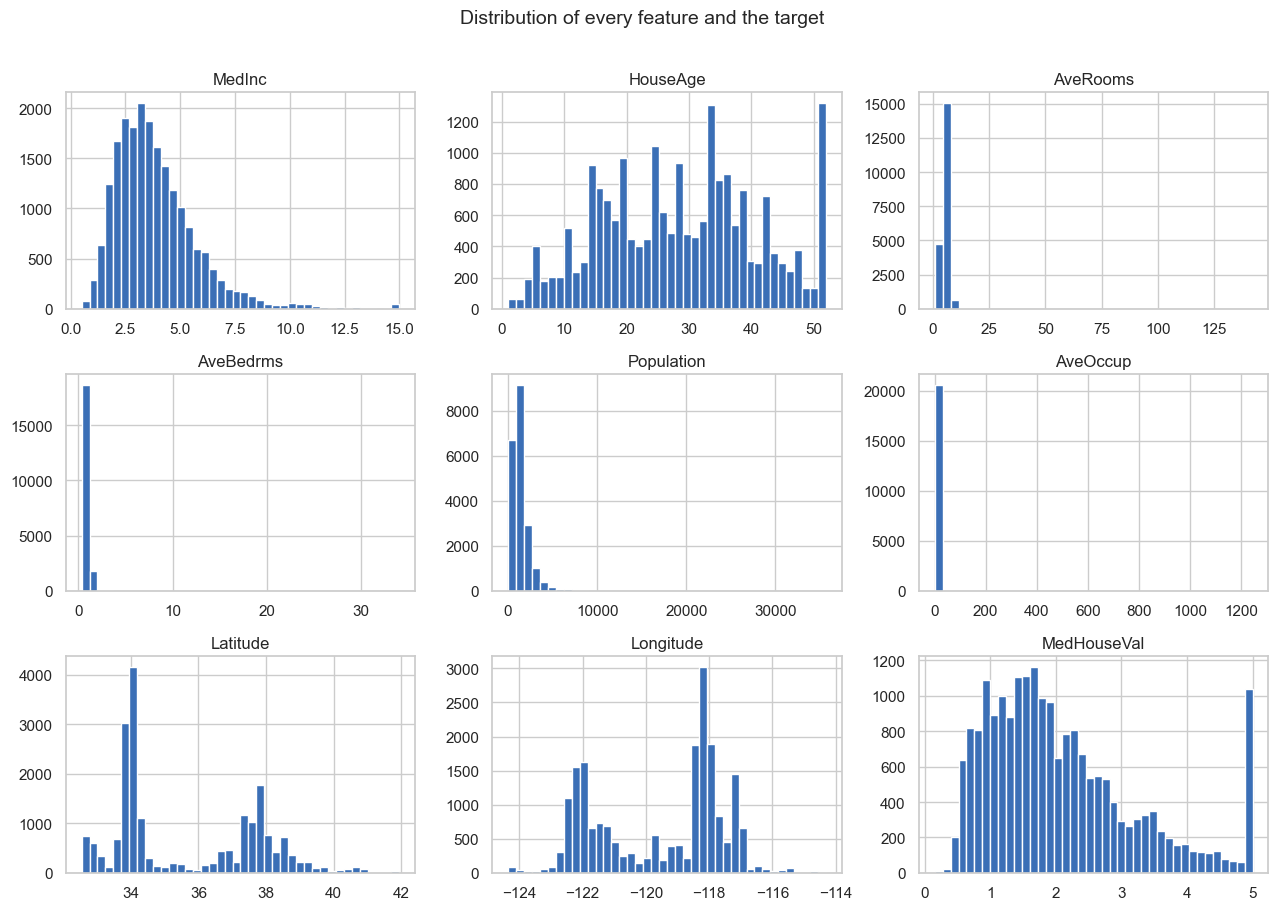

Target is capped at 5.00001: 965 rows (4.7%) sit at the cap.


In [6]:
axes = df.hist(bins=40, figsize=(13, 9), color="#3b6fb6", edgecolor="white")
plt.suptitle("Distribution of every feature and the target", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

cap = df["MedHouseVal"].max()
n_cap = int((df["MedHouseVal"] >= cap).sum())
print(f"Target is capped at {cap:.5f}: {n_cap} rows ({n_cap / len(df):.1%}) sit at the cap.")

**What the distributions show**
- `AveRooms`, `AveBedrms`, `AveOccup` and `Population` look like a single spike because a few extreme block groups (e.g. an average of 140+ rooms or 1,200+ people per household) stretch the axis. The medians are far more typical (see the quantile table above). These are likely block groups with very few households.
- The target `MedHouseVal` is **capped** at 5.0 (about $500k): the spike at the right edge is over 4% of the rows. `HouseAge` (52) and `MedInc` (15) also show pile-ups at their maximum. A linear model cannot learn what happens above these caps.
- Latitude and longitude are bimodal, reflecting the two population centres (Bay Area and Los Angeles).

### 3.3 Correlations

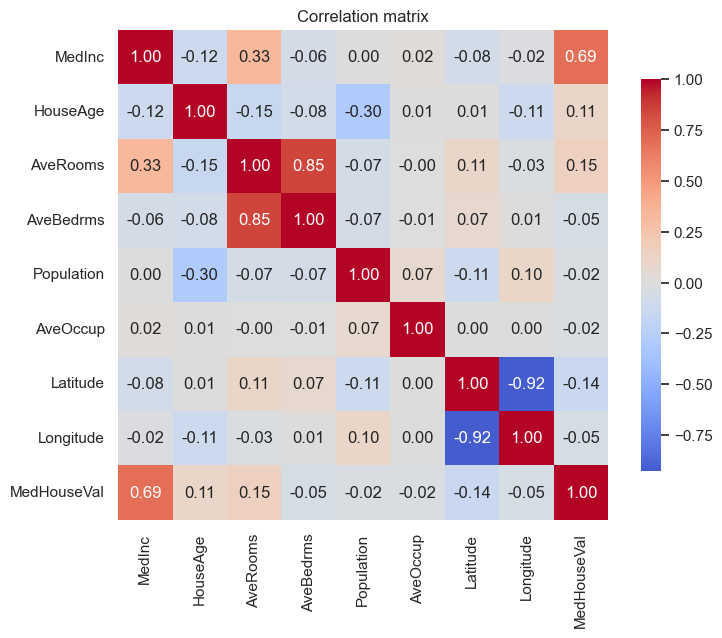

Correlation with MedHouseVal:
MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144


In [7]:
corr = df.corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with MedHouseVal:")
print(corr["MedHouseVal"].drop("MedHouseVal").sort_values(ascending=False).round(3).to_string())

**What the correlations show**
- `MedInc` is by far the strongest predictor of house value (r ≈ 0.69). The other features have weak *linear* correlation with the target (|r| of about 0.15 or less).
- `Latitude` and `Longitude` are almost perfectly negatively correlated (r ≈ -0.92) because California runs diagonally. `AveRooms` and `AveBedrms` are also strongly correlated. This **multicollinearity** makes individual coefficients unstable and hard to interpret.

### 3.4 Income and location vs house value

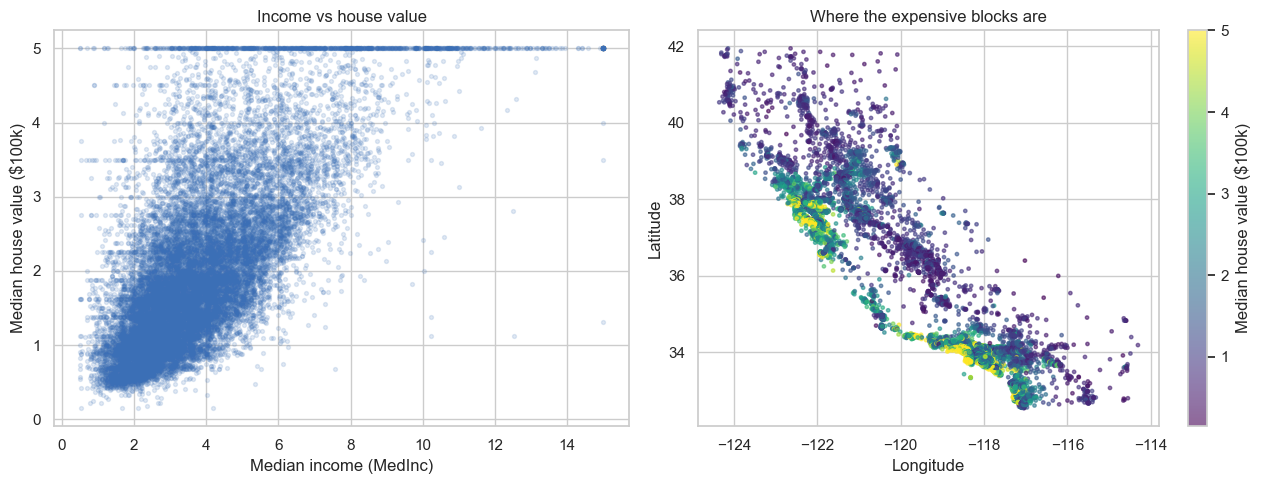

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["MedInc"], df["MedHouseVal"], alpha=0.15, s=8, color="#3b6fb6")
axes[0].set_xlabel("Median income (MedInc)")
axes[0].set_ylabel("Median house value ($100k)")
axes[0].set_title("Income vs house value")

sc = axes[1].scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis", s=6, alpha=0.6)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Where the expensive blocks are")
fig.colorbar(sc, ax=axes[1], label="Median house value ($100k)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_income_and_map.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaways**
- Income and price rise together, but the relationship is noisy and flattens against the $500k cap (the horizontal line at the top).
- Location matters a lot and is *non-linear*: expensive blocks cluster along the coast (Bay Area, Los Angeles, San Diego) while inland areas are cheap. A straight-line function of latitude/longitude cannot describe this pattern, which limits a linear model.

## 4. Preprocessing: features, target and train/test split
- The data has **no missing values**, so no imputation is needed.
- Plain `LinearRegression` (ordinary least squares) is not affected by feature scale, so scaling is skipped here; it matters for the regularised models in section 8.
- All 8 features are used. The 80/20 split with a fixed `random_state` keeps the run reproducible, and the test set stays untouched until evaluation.

In [9]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows | Features: {X_train.shape[1]}")

Train: 16512 rows | Test: 4128 rows | Features: 8


## 5. Train the model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

coefs = pd.Series(model.coef_, index=X.columns).sort_values()
print(f"Intercept: {model.intercept_:.4f}\n")
print(coefs.round(4).to_string())

Intercept: -37.0233

Longitude    -0.4337
Latitude     -0.4198
AveRooms     -0.1233
AveOccup     -0.0035
Population   -0.0000
HouseAge      0.0097
MedInc        0.4487
AveBedrms     0.7831


**Reading the coefficients**
- Each coefficient is the change in predicted value (in $100k) for a one-unit increase in that feature, holding the others fixed. Coefficients are not comparable across features because the features are on different scales.
- `MedInc` has the expected positive effect. `Latitude` and `Longitude` are negative, so the model pushes prices down towards the north and east, which is a crude straight-line approximation of the coastal effect.
- `AveBedrms` is positive while `AveRooms` is negative. This is counter-intuitive and is a symptom of the multicollinearity noted earlier, so these two coefficients should not be over-interpreted.

## 6. Evaluate the model
- **MAE**: average absolute error (same unit as the target, $100k)
- **RMSE**: square root of the mean squared error; penalises large mistakes more than MAE
- **R²**: share of the variance in house prices the model explains (1 = perfect, 0 = no better than predicting the mean)

A `DummyRegressor` that always predicts the training mean is the baseline to beat.

In [11]:
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

results = pd.DataFrame({
    "Baseline (predict mean), test": evaluate(y_test, baseline.predict(X_test)),
    "Linear Regression, train":      evaluate(y_train, model.predict(X_train)),
    "Linear Regression, test":       evaluate(y_test, y_pred),
}).T
display(results.round(4))

m = evaluate(y_test, y_pred)
print(f"MAE: {m['MAE']:.3f}  RMSE: {m['RMSE']:.3f}  R2: {m['R2']:.3f}")
print(f"In dollars, the typical (mean absolute) error is about ${m['MAE'] * 100_000:,.0f}.")

# Save the numbers so the PDF report can be built from this exact run
metrics_out = {
    "baseline_test": evaluate(y_test, baseline.predict(X_test)),
    "linreg_train": evaluate(y_train, model.predict(X_train)),
    "linreg_test": m,
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "intercept": float(model.intercept_),
    "coefficients": {k: float(v) for k, v in zip(X.columns, model.coef_)},
}

,MAE,RMSE,R2
"Baseline (predict mean), test",0.9061,1.1449,-0.0002
"Linear Regression, train",0.5286,0.7197,0.6126
"Linear Regression, test",0.5332,0.7456,0.5758


MAE: 0.533  RMSE: 0.746  R2: 0.576
In dollars, the typical (mean absolute) error is about $53,320.


**Interpretation**
- The model clearly beats the mean-only baseline (R² ≈ 0), explaining roughly 57-58% of the variance in house prices.
- Train and test scores are close, so the model is **not overfitting**. It is limited by *underfitting*: a straight-line model is too simple for this data.
- The typical error is about $53k on houses whose median value is about $180k, which is large in relative terms. The RMSE is noticeably above the MAE, meaning there are some large misses.

## 7. Diagnostic plots: predicted vs actual, residuals

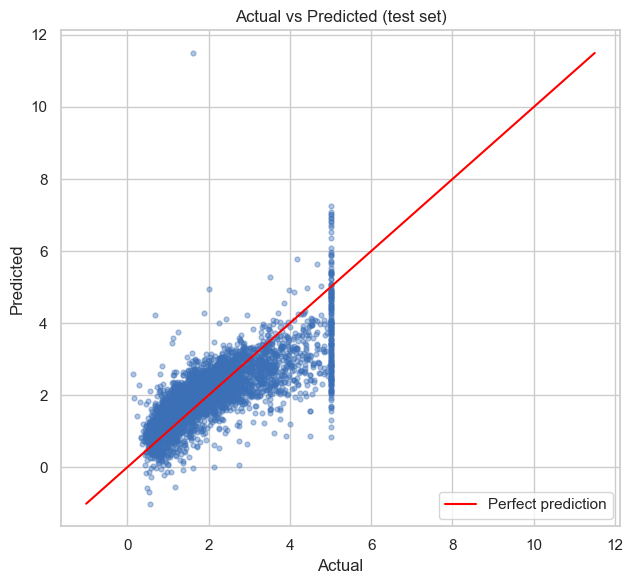

In [12]:
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=12, color="#3b6fb6")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", label="Perfect prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

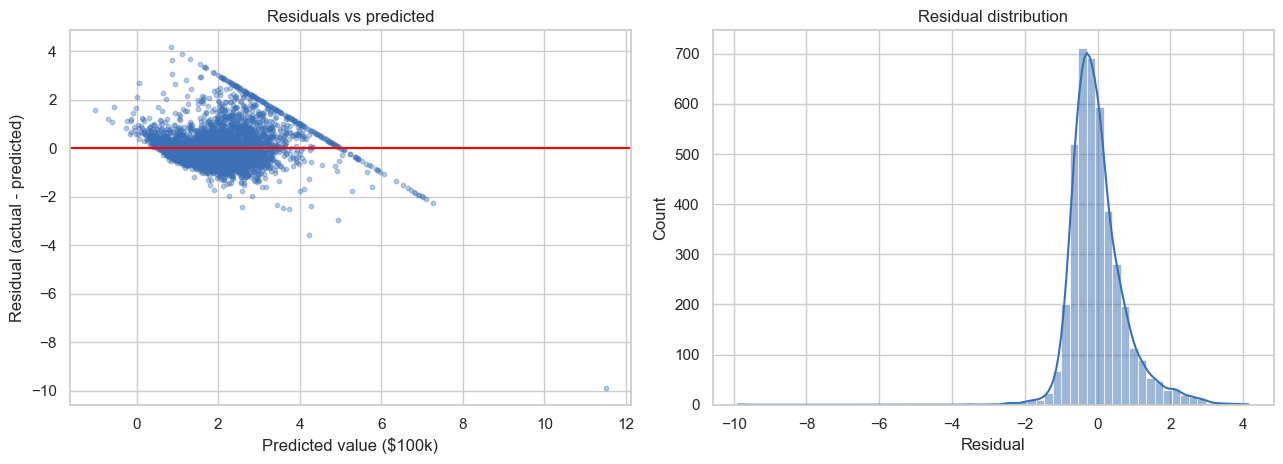

Mean residual: 0.003 | Std of residuals: 0.746
Test rows predicted below 0: 15


In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(y_pred, residuals, alpha=0.35, s=10, color="#3b6fb6")
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Predicted value ($100k)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted")

sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="#3b6fb6")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean residual: {residuals.mean():.3f} | Std of residuals: {residuals.std():.3f}")
print(f"Test rows predicted below 0: {(y_pred < 0).sum()}")

**What the diagnostics show**
- Points follow the red line only loosely, and the model **under-predicts expensive houses** (the vertical stripe at actual = 5.0 is the capped rows).
- The residuals are centred on zero, but the diagonal band in the residual plot is the capped rows again (residual = 5.0 - prediction). The spread also widens for higher predictions (*heteroscedasticity*), which breaks an assumption of ordinary least squares.
- A few predictions are negative (or absurdly high, for one row with extreme feature values). Linear regression has no built-in bound on its output.

## 8. Improvement ideas: a quick experiment
The brief only asks for `LinearRegression`, but a good report also says how to do better. Here the baseline is compared with two alternatives using **5-fold cross-validation on the training set**, plus their test scores. Cross-validation gives a more stable estimate than a single split.

- **Ridge** (with scaling): regularised linear model, useful when features are correlated
- **HistGradientBoosting**: a tree-based model that captures non-linear effects and interactions (e.g. latitude × longitude)

In [14]:
candidates = {
    "Linear Regression": LinearRegression(),
    "Ridge (scaled)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = {}
for name, est in candidates.items():
    cv_r2 = cross_val_score(est, X_train, y_train, cv=5, scoring="r2")
    est.fit(X_train, y_train)
    rows[name] = {"CV R2 (mean)": cv_r2.mean(), "CV R2 (std)": cv_r2.std(), **{f"Test {k}": v for k, v in evaluate(y_test, est.predict(X_test)).items()}}

comparison = pd.DataFrame(rows).T
display(comparison.round(4))
metrics_out["comparison"] = {k: {kk: float(vv) for kk, vv in v.items()} for k, v in comparison.T.to_dict().items()}

# Write the metrics file used by the report
with open("metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

,CV R2 (mean),CV R2 (std),Test MAE,Test RMSE,Test R2
Linear Regression,0.6115,0.0065,0.5332,0.7456,0.5758
Ridge (scaled),0.6115,0.0065,0.5332,0.7456,0.5758
HistGradientBoosting,0.8325,0.0053,0.3111,0.4654,0.8347


**What the experiment shows**
- **Ridge gives essentially the same score as plain linear regression.** Regularisation does not help, which confirms the problem is model *flexibility*, not overfitting or multicollinearity noise.
- **HistGradientBoosting improves R² from about 0.57 to about 0.83 and cuts the MAE by roughly 40%**, because it can capture the non-linear location effect and feature interactions.

**Other ideas to try**
1. **Handle the outliers and caps:** clip extreme `AveRooms`/`AveOccup`, or drop the capped rows from training and evaluation.
2. **Transform the target:** model `log(MedHouseVal)` to reduce skew and stabilise the residual spread.
3. **Feature engineering:** distance to the coast or to major cities, rooms-per-person, bedroom ratio (`AveBedrms / AveRooms`), and lat × lon interactions.
4. **Non-linear terms:** `PolynomialFeatures` on `MedInc` and the location features.
5. **Better validation and tuning:** cross-validation with `GridSearchCV`, and a check of the error by price bracket.

## 9. Save the model
The trained `LinearRegression` model is saved with `pickle` and reloaded to confirm it gives identical predictions.

In [15]:
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("linear_regression_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

assert np.allclose(loaded_model.predict(X_test), y_pred), "Reloaded model gives different predictions!"
print("Model saved to linear_regression_model.pkl and reloaded successfully.")

# Predict on a new, made-up block group (column names must match the training data)
new_house = pd.DataFrame([{
    "MedInc": 5.0, "HouseAge": 20.0, "AveRooms": 6.0, "AveBedrms": 1.0,
    "Population": 1200.0, "AveOccup": 3.0, "Latitude": 34.05, "Longitude": -118.25,
}])
pred = loaded_model.predict(new_house)[0]
print(f"Predicted median house value: {pred:.2f} (about ${pred * 100_000:,.0f})")

Model saved to linear_regression_model.pkl and reloaded successfully.
Predicted median house value: 2.44 (about $243,682)


## 10. Conclusions

- A plain linear regression on all 8 features explains roughly 57-58% of the variance in California house prices, with a typical error near $53k. It is a solid, interpretable baseline.
- **Median income** is the dominant driver of house value; **location** is the second, but its effect is non-linear.
- Two properties of the data limit the model: the **$500k cap on the target** and **outliers/multicollinearity** in the room and occupancy features.
- The biggest single upgrade is moving to a non-linear model (a gradient-boosting model reaches R² ≈ 0.83 in the experiment above), and cheap wins are available from feature engineering and a log-transformed target.
- The trained model is saved as `linear_regression_model.pkl` and all figures are in `figures/`.